In [1]:
import math
import copy
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error as MAPE
from matplotlib.lines import Line2D
from Testing.RTLO_R2 import *
from Functions.RLS import *
from Functions.Utils import *
from Functions.Utils_RTLO import *
from Functions.Graphs import *
from Functions.TedaGraphs import *

import optuna
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_pareto_front
from optuna.importance import get_param_importances
from optuna.samplers import RandomSampler

df = pd.read_csv(r'Dataset\Dataset_1_NCA_battery_SoH\CY25-05_1-#01.csv')
sig = df['soh'].values

df = pd.read_csv(r'Dataset\Bearing1_1.csv')
#sig = df['PC1'].values

RS = pd.read_excel(r'Dataset\RS.xlsx')
HI = pd.read_excel(r'Dataset\HI.xlsx')


In [2]:
def euclidian_dist(x1,x2):
    return np.linalg.norm(x1 - x2,ord=None)

class DataCloud:
	N=0
	def __init__(self,x,ID,nI=1,nR=1,nO=1,ηS=[1,1,1],tau=1,mode='past'):
		self.ID = ID
		self.track = [ID]
		self.merged = False
		self.merge = None
		self.n=1
		self.mean=x
		self.meant=np.array(x).dot(np.array(x))
		self.variance=0
		self.pertinency=1
		self.tipicality=1e-12
		self.nI = nI
		self.nR = nR
		self.nO = nO
		self.N1 = ηS[0]
		self.N2 = ηS[1]
		self.N3 = ηS[2]
		self.mode = mode
		self.tau = tau
		self.rnn = RTLO(self.nI, self.nR, self.nO,
					[self.N1, self.N2, self.N3], self.tau, self.mode)
		self.x = [x]
		self.rul = np.array([])
		self.t = []
		self.R = 0
		self.xI = x
		self.xF = x
		self.Rmax = 0
		self.specificity = 0
		self.coverage = 0
		self.cardinality = 1
		self.v = 0
		self.Dmax = -np.inf
		
	def addDataClaud(self,x):
		self.n=2
		self.mean=(self.mean+x)/2
		self.meant=((self.meant)/2) + (x.dot(x))/2
		self.variance=self.meant-self.mean.dot(self.mean)

	def updateDataCloud(self,n,mean,meant,variance,tipicality):
		self.n=n
		self.mean=mean
		self.meant=meant
		self.variance=variance
		self.tipicality=tipicality
		self.cardinality=self.cardinality + 1

In [214]:
class AutoCloud:
	def __init__(self,m,nI=1,nR=1,nO=1,ηS=[0.1,0.1,0.1],
			  tau=1,eol=0,mode='past',st=0,end=0,ep=0.003,wta=True):
		
		self.ep = ep
		self.st = st
		self.mode = mode
		self.end = end
		self.nI = nI
		self.nR = nR
		self.nO = nO
		self.N1 = ηS[0]
		self.N2 = ηS[1]
		self.N3 = ηS[2]
		self.tau = tau
		self.eol = eol
		self.y = None
		self.g = 1
		self.gCreated = 0
		self.c= np.array([])
		self.alfa= np.array([0.0],dtype=float)
		self.intersection = np.zeros((1,1),dtype=int)
		self.listIntersection = np.zeros((1),dtype=int)
		self.matrixIntersection = np.zeros((1,1),dtype=int)
		self.relevanceList = np.zeros((1),dtype=int)
		self.classIndex = []
		self.k=1
		self.m = m
		self.cloud_activation = []
		self.aux = np.array([])
		self.DSIs = [np.array([]) for i in range(nI)]
		self.OffineGrnls = None

		self.eolX = 0
		self.HI = np.array([])
		self.DSI = np.array([])
		self.eolDSI = 0
		self.HIp = np.array([])
		self.cycleP=np.array([])

		self.rulL = np.array([])
		self.rulP = np.array([])
		self.rulP2 = np.array([])
		self.rulU = np.array([])
		self.rulR = np.array([])
		self.ref = 0
		self.rulR2 = np.array([])
		self.rulR_Train = np.array([])
		self.lim = 160

		self.hiR = np.array([])
		self.hiP = np.array([])

		self.rls = RLS_LogarithmicRegressor(0.9,10000)
		self.εP = []
		self.εR = []
		self.win_all = wta
		self.ChangePoint = []
		self.xR = 0
		self.xF = 0
		self.Dmax = 0
	
	def CreateCloud(self,x):
		self.gCreated = self.gCreated + 1
		cloud = DataCloud(x,self.gCreated,self.nI,self.nR,self.nO,
					[self.N1,self.N2,self.N3],self.tau,self.mode)
		self.c = np.append(self.c,cloud)

	def add_rulR2(self,n):
		self.rulR2 = np.append(self.rulR2,n)

	def Adapt(self,y,z):
		wMax = 0
		self.HI = np.append(self.HI,z[-1])

		ws = self.alfa/np.sum(self.alfa)
		
		for w,cloud in zip(ws,self.c):
			if w > wMax:
				wMax = w
				Best_cloud = cloud

		if self.win_all:
			Best_cloud.rnn.fit(y,z)
		if not self.win_all:
			for i,cloud in enumerate(self.c):
				cloud.rnn.fit(y,z)
	

	def predict(self,y,show=False):
		ws = self.alfa/np.sum(self.alfa)
		p = (np.array([w*cloud.rnn.Predict(y) for cloud,w in zip(self.c,ws)]))
		#if show: print(self.k,p)
		p = np.sum(p)

		return p
	
	def DefRnnParams(self, cloud):
		n = len(self.c[:-1])
		params_ = [[] for i in range(8)]
		for c in self.c[:-1]:
			params = c.rnn.ReturnParameters()
			for i,p in enumerate(params):
				params_[i].append(p)
		params = [sum(p)/n for p in params_]
		cloud.rnn.ReceiveParameters(params)

	def MergeCloudsRNN(self, c1, c2, c3):
		ps1 = c1.rnn.ReturnParameters()
		ps2 = c2.rnn.ReturnParameters()
		params = [(ps1[i]+ps2[i])/2 for i in range(len(ps2))]
		c3.rnn.ReceiveParameters(params)
		
	def RULSingle(self,X,show=False):
		rulP = 0
		lim =160
		xP = X.copy()

		if show:
				for c in self.c:
					print('PS',c.rnn.hP[:3],c.rnn.hP2[:3])
		
		while xP[-1]>self.eol:
			
			#if show: print(self.k,xP[-3:])
			pP = self.predict(xP,show)
			if show: print(rulP,pP)
			xP = np.delete(np.append(xP,pP),0)
			
			#if show and rulP<5:
				#print('PS',self.k,ws,xP[-3:])

			if rulP == lim: 
				rulP = 1
				break
			
			rulP=rulP+1
		self.rulR = np.append(self.rulR,self.ref - self.k)
		self.rulP = np.append(self.rulP,rulP)
		self.rulL = np.append(self.rulL,0)
		self.rulU = np.append(self.rulU,0)

		for cloud in self.c:
			cloud.rnn.Restore()
		#print(rulP)
		return
	
	def RULInterv(self,X,show=False):
		lim = 160
		xP,xL,xU = X.copy(),X.copy(),X.copy()
		predict = True
		Ruls = [0 for i in range(3)]
		CheckRuls = [True for i in range(3)]
		PredVals = np.zeros(3)
		
		if show:
				for c in self.c:
					print('PI',c.rnn.hP[:3],c.rnn.hP2[:3])

		while predict:
			cont = 0
			
			ws = self.alfa/np.sum(self.alfa)
		
			Pred = [w*c.rnn.PredictIntr(xP,xL,xU,self.ep) for w,c in zip(ws,self.c)]
			#print(self.k,ws,sum(Pred),'---')
			#PredVals = sum([ws[i]*c.rnn.PredictIntr(xP,xL,xU,self.ep) for i,c in enumerate(self.c)])
			PredVals = sum(Pred)
			yL,yP,yU = PredVals

			if show: 
				print(self.k,Ruls[1],PredVals[1])

			#print(PredVals, Ruls)
			#print(xP[-3:])
			xP = np.delete(np.append(xP,yP),0)
			xL = np.delete(np.append(xL,yL),0)
			xU = np.delete(np.append(xU,yU),0)

			for j,_ in enumerate(Ruls):
				if CheckRuls[j]:
					Ruls[j] = Ruls[j] + 1

				if Ruls[j] > lim:
					CheckRuls[j] = False
					Ruls[j] = lim

			for j,_ in enumerate(CheckRuls):
				if PredVals[j] <= self.eol:
					CheckRuls[j] = False

				if not CheckRuls[j]:
					cont = cont + 1
			
			if cont == 3:
				break
		
			
		for cloud in self.c:
			cloud.rnn.Restore()

		if Ruls[2] < Ruls[1]:
			Ruls[2] = Ruls[1] 
		self.rulR = np.append(self.rulR,self.ref - self.k)
		self.rulP = np.append(self.rulP,Ruls[1])
		self.rulL = np.append(self.rulL,Ruls[0])
		self.rulU = np.append(self.rulU,Ruls[2])

	def RUL_uncertainty(self,X,Y):
		xP, rulP = X.copy(), 0
		yP = self.predict(xP)*self.fator
		yR = Y[-1]
		εR = abs(yP-yR)
		
		self.rls.update(np.abs(yP), εR)
		RNNs = np.array([copy.deepcopy(cloud.rnn) for cloud in self.c])
		while xP[-1]>self.eol:
			yP = self.propagate(xP,RNNs)*self.fator
			xP = np.delete(np.append(xP,yP),0)
			rulP=rulP+1
			if rulP == self.lim: break
		
		self.rulL = np.append(self.rulL,self.RulCalc(X,lower=True))
		self.rulU = np.append(self.rulU,self.RulCalc(X,lower=False))
		self.rulP = np.append(self.rulP,rulP)

		return
	
	def AddRUL(self):
		for cloud in self.cloud_activation:
			cloud.rul = np.append(cloud.rul,self.rulP[-1])
		self.cloud_activation = []
	
	def mergeClouds(self,x):
		i=0
		while(i<len(self.listIntersection)-1):
			merge=False
			j=i+1
			while(j<len(self.listIntersection)):
				if(self.listIntersection[i] == 1 and self.listIntersection[j] == 1):
					self.matrixIntersection[i,j] = self.matrixIntersection[i,j] + 1
				idI = self.c[i].ID
				idJ = self.c[j].ID
				meanI = self.c[i].mean
				meanJ = self.c[j].mean
				meantI = self.c[i].meant
				meantJ = self.c[j].meant
				nI = self.c[i].n
				nJ = self.c[j].n
				tipicalityI = self.c[i].tipicality
				tipicalityJ = self.c[j].tipicality
				trackI = self.c[i].track
				trackJ = self.c[j].track
				varianceI = self.c[i].variance
				varianceJ = self.c[j].variance
				winI = self.c[i].rnn.wI
				winJ = self.c[j].rnn.wI
				wrecI = self.c[i].rnn.wR
				wrecJ = self.c[j].rnn.wR
				woutI = self.c[i].rnn.wO
				woutJ = self.c[j].rnn.wO
				hiI = self.c[i].rnn.hP
				hiJ = self.c[j].rnn.hP
				nIntersc = self.matrixIntersection[i,j]

				if (nIntersc > (nI - nIntersc) or nIntersc > (nJ - nIntersc)):
					rI = np.max(self.c[i].R)
					rJ = np.max(self.c[j].R)
					if rI >= rJ: radius = rI
					else: radius = rJ
					merge = True
					self.gCreated = self.gCreated + 1
					n = nI + nJ - nIntersc
					mean = ((nI * meanI) + (nJ * meanJ))/(nI + nJ)
					meant = ((nI * meantI) + (nJ * meantJ))/(nI + nJ)
					variance = ((nI - 1) * varianceI + (nJ - 1) * varianceJ)/(nI + nJ - 2)
					tipicality = ((nI*tipicalityI)+(nJ*tipicalityJ))/(nI + nJ)
					wIN = ((winI*tipicalityI)+(winJ*tipicalityJ))/(tipicalityI+tipicalityJ)
					wHS = ((wrecI*tipicalityI)+(wrecJ*tipicalityJ))/(tipicalityI+tipicalityJ)
					wOUT = ((woutI*tipicalityI)+(woutJ*tipicalityJ))/(tipicalityI+tipicalityJ)
					hI = ((hiI*tipicalityI)+(hiJ*tipicalityJ))/(tipicalityI+tipicalityJ)

					newCloud = DataCloud(x,self.gCreated,self.nI,self.nR,self.nO,
									[self.N1,self.N2,self.N3],self.tau,self.mode)
					for id in trackI:
						newCloud.track.append(id)
					for id in trackJ:
						newCloud.track.append(id)
						
					newCloud.updateDataCloud(n,mean,meant,variance,tipicality)
					newCloud.R = radius
					
					x = self.c[i].x + self.c[j].x
					t = self.c[i].t + self.c[j].t
					mat = np.array(list(zip(t,x)), dtype=object)
					col = mat[:, 0].astype(int) 
					_, index = np.unique(col, return_index=True)
					result = mat[np.sort(index)]
					t = result[:, 0].tolist()
					x = result[:, 1].tolist()
					newCloud.x = x
					newCloud.t = t
					dist = 0
					if euclidian_dist(self.c[i].xI,self.c[i].xF) > dist:
						dist = euclidian_dist(self.c[i].xI,self.c[i].xF)
						newCloud.xI = self.c[i].xI
						newCloud.xF = self.c[i].xF
					elif euclidian_dist(self.c[j].xI,self.c[j].xF) > dist:
						dist = euclidian_dist(self.c[j].xI,self.c[j].xF)
						newCloud.xI = self.c[j].xI
						newCloud.xF = self.c[j].xF
					elif euclidian_dist(self.c[i].xI,self.c[j].xF) > dist:
						dist = euclidian_dist(self.c[i].xI,self.c[j].xF)
						newCloud.xI = self.c[i].xI
						newCloud.xF = self.c[j].xF
					elif euclidian_dist(self.c[j].xI,self.c[i].xF) > dist:
						dist = euclidian_dist(self.c[j].xI,self.c[i].xF)
						newCloud.xI = self.c[j].xI
						newCloud.xF = self.c[i].xF
	
					self.MergeCloudsRNN(self.c[i],self.c[j],newCloud)
					newCloud.merge = f'G{self.gCreated}: G{idI}+G{idJ}'

					self.cloud_activation.append(newCloud)
					self.aux = np.append(self.aux,newCloud.ID)

					self.listIntersection = np.concatenate((self.listIntersection[0 : i], np.array([1]), self.listIntersection[i + 1 : j],self.listIntersection[j + 1 : np.size(self.listIntersection)]),axis=None)
					self.c = np.concatenate((self.c[0 : i ], np.array([newCloud]), self.c[i + 1 : j],self.c[j + 1 : np.size(self.c)]),axis=None)
					M0 = self.matrixIntersection
					M1=np.concatenate((M0[0 : i , :],np.zeros((1,len(M0))),M0[i + 1 : j, :],M0[j + 1 : len(M0), :]))
					M1=np.concatenate((M1[:, 0 : i ],np.zeros((len(M1),1)),M1[:, i+1 : j],M1[:, j+1 : len(M0)]),axis=1)
					col = (M0[:, i] + M0[:, j])*(M0[: , i]*M0[:, j] != 0)
					col = np.concatenate((col[0 : j], col[j + 1 : np.size(col)]))
					lin = (M0[i, :]+M0[j, :])*(M0[i, :]*M0[j, :] != 0)
					lin = np.concatenate((lin[ 0 : j], lin[j + 1 : np.size(lin)]))
					M1[:,i]=col
					M1[i,:]=lin
					M1[i, i + 1 : j] = M0[i, i + 1 : j] + M0[i + 1 : j, j].T;   
					self.matrixIntersection = M1

				j += 1
			if(merge): 
				i = 0
			else: i += 1

	def run(self,X):
		self.aux = np.array([])
		self.aux2 = np.array([])
		self.listIntersection = np.zeros((np.size(self.c)),dtype=int)
		if self.k == 1: self.xR = X
		if self.k==1:
			self.CreateCloud(X)
			self.c[0].t.append(self.k)
			self.aux = np.append(self.aux,1)
			self.aux2 = np.append(self.aux,self.c[0].track)

			self.alfa = np.ones(1)
			self.cloud_activation.append(self.c[0])

		elif self.k==2:
			self.c[0].addDataClaud(X)
			self.c[0].x.append(X)
			self.c[0].t.append(self.k)
			v = self.c[0].variance
			n = self.c[0].n
			R = math.sqrt((((self.m**2)+1)*n*v/n)-v)
			self.c[0].R = R
			self.c[0].cardinality = self.c[0].cardinality+1
			self.aux = np.append(self.aux,1)
			self.aux2 = np.append(self.aux,self.c[0].track)
			self.alfa = np.ones(1)
			self.cloud_activation.append(self.c[0])

		elif self.k>=3:
			i=0
			createCloud = True
			self.alfa = np.zeros((np.size(self.c)),dtype=float)
			
			for cloud in self.c:
				n= cloud.n +1
				mean = ((n-1)/n)*cloud.mean + (1/n)*X
				
				meant = ((n-1)/n) * cloud.meant + (X.dot(X))/n
				variance=meant-mean.dot(mean)
				eccentricity = (1/n)+((mean-X).T.dot(mean-X))/(n*variance)
				typicality = 1 - (eccentricity-(1e-12))
				norm_eccentricity = eccentricity/2
				norm_typicality = typicality/(self.k-2)
				cloud.eccAn = eccentricity
				R = math.sqrt((((self.m**2)+1)*n*variance/n)-variance)
				if(norm_eccentricity<=(self.m**2 +1)/(2*n)):
					createCloud= False
					cloud.updateDataCloud(n,mean,meant,variance,norm_typicality)
					self.alfa[i] = norm_typicality
					self.listIntersection[i] = 1

					cloud.x.append(X)
					cloud.t.append(self.k)
					cloud.xF = X
					cloud.R = R
					self.aux = np.append(self.aux,cloud.ID)
					self.aux2 = np.append(self.aux2,cloud.track)
					self.cloud_activation.append(cloud)
				else:
					self.alfa[i] = 0
					self.listIntersection[i] = 0
				i+=1
			#print(self.alfa)
			if(createCloud):
				#print('create',self.k)
				self.CreateCloud(X)
				self.listIntersection = np.insert(self.listIntersection,i,1)
				self.matrixIntersection = np.pad(self.matrixIntersection, ((0,1),(0,1)), 'constant', constant_values=(0)) 
				self.c[-1].t.append(self.k)
				self.c[-1].R = 0
				
				self.DefRnnParams(self.c[-1])

				self.aux = np.append(self.aux,self.c[-1].ID)
				self.aux2 = np.append(self.aux2,self.c[-1].track)
				self.cloud_activation.append(self.c[-1])
				self.alfa = np.append(self.alfa,1)
			self.mergeClouds(X)

		if self.Dmax < euclidian_dist(x1=self.xR, x2=X):
			self.Dmax = euclidian_dist(x1=self.xR, x2=X)
			self.xF = X

		self.cycleP = np.append(self.cycleP,self.st+self.k-1)
		self.rulR_Train = np.append(self.rulR_Train,self.end-self.k)
		self.k=self.k+1

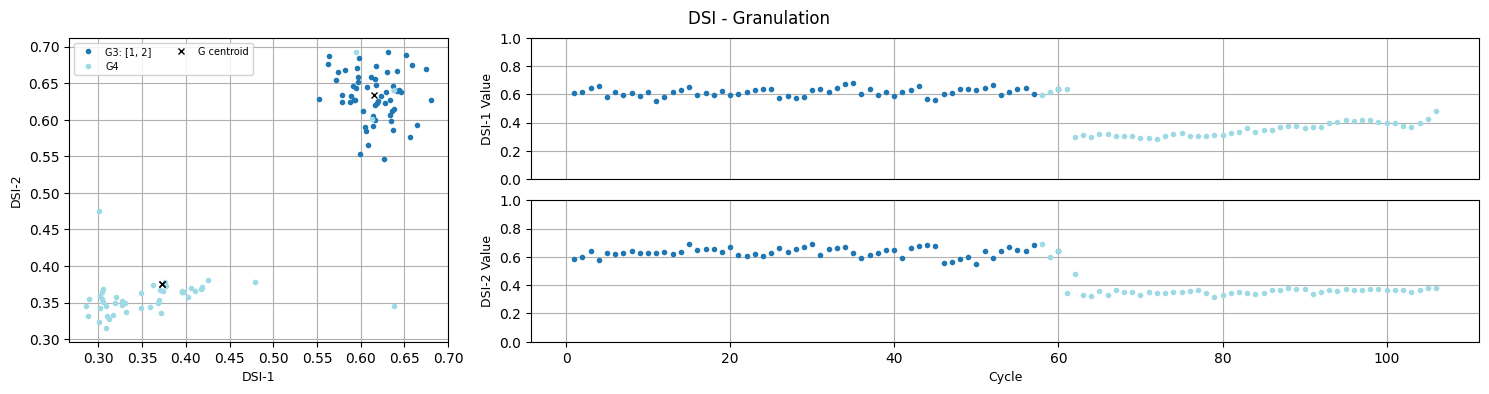

In [219]:
params =  {'nI': 11, 'nR': 49, 'nO': 27, 'N1': 0.1, 'N2': 0.0001, 'N3': 0.001, 'τ': 23, 'mode': 'ahead', 'act': 'tanh'}
nI,nR,nO,N1,N2,N3,τ,mode,act= list(params.values())

dsi, Z = PrepareData(HI['PC1'].values,nI,nO,mode)
dsi, Z = PrepareData(sig,nI,nO,mode)
X, Y = dsi, dsi
X = []

for i in range(len(RS)-1):
   X.append(RS.iloc[i:i+3,:].values.flatten())
X = X[-len(Y):-2]
teda=AutoCloud(m=1.7,nI=nI,nR=nR,nO=nO,ηS=[N1,N2,N3],
               mode=mode,tau=τ,eol=0.75) 
teda.ref = len(sig) - nI
for j,_ in enumerate(X[:]):
    teda.run(X[j])
    #print(j,teda.alfa)

    #teda.RULSingle(Y[j])
    teda.RULInterv(Y[j])

    teda.Adapt(Y[j],Z[j])
    

plot_DSI2(teda,ftrs=2,title='DSI - Granulation',ncol=2,mergeID=True)
PlotSeriesPLY(ySeries=[teda.rulR,teda.rulP,teda.rulL,teda.rulU],
              names = ['r','p','L','u'],w=800,h=400)

In [5]:
rnn2 = RTLO(nI,nR,nO)
print(rnn2.wR[0][:5])

prm = teda.c[-1].rnn.ReturnParameters()
rnn2.ReceiveParameters(prm)
print(teda.c[-1].rnn.wR[0][:5])

print(rnn2.wR[0][:5])


[-0.12326084 -0.22462431  0.08750135 -0.22592401 -0.18982104]
[-0.12324613 -0.22460091  0.08753406 -0.2259279  -0.18982643]
[-0.12324613 -0.22460091  0.08753406 -0.2259279  -0.18982643]


In [6]:
'''m,nHI,nR,N1,N2,N3,D,tau = Mp2
X, Y = PrepareDataPast(sig,nHI,nHI)
xS,yS,zS = X, X, Y
teda=AutoCloud(m=m, nS=len(xS[0]), nI=len(yS[0]), nR=nR, nO=len(yS[0]), 
                            ηS= [N1, N2, N3], tau=tau, decay=D,eol=0.8,
                            fator=1,st=0,end=len(X)-nRS,wta=True,ep=0.1) 

for j,_ in enumerate(xS[:]):
    x,y,z= xS[j],yS[j],zS[j]
    teda.run(x)
    teda.adapt(y,z)
    #teda.RUL_single(y)
    teda.RUL_uncertainty(y,z)
    teda.AddRUL()
    #print(teda.rulP)

x = teda.cycleP
yL,yP,yU,yR = teda.rulL,teda.rulP,teda.rulU,teda.rulR
print(MAPE(yR,yP))
#plot_series(series=[[x,x,x,x],[yL,yP,yU,yR]],names=['L','P','U','R'],show=False)
plot_RUL_CI(teda,startX=0,endX=120,endY=165,w=12,h=5,mk1=5)'''

"m,nHI,nR,N1,N2,N3,D,tau = Mp2\nX, Y = PrepareDataPast(sig,nHI,nHI)\nxS,yS,zS = X, X, Y\nteda=AutoCloud(m=m, nS=len(xS[0]), nI=len(yS[0]), nR=nR, nO=len(yS[0]), \n                            ηS= [N1, N2, N3], tau=tau, decay=D,eol=0.8,\n                            fator=1,st=0,end=len(X)-nRS,wta=True,ep=0.1) \n\nfor j,_ in enumerate(xS[:]):\n    x,y,z= xS[j],yS[j],zS[j]\n    teda.run(x)\n    teda.adapt(y,z)\n    #teda.RUL_single(y)\n    teda.RUL_uncertainty(y,z)\n    teda.AddRUL()\n    #print(teda.rulP)\n\nx = teda.cycleP\nyL,yP,yU,yR = teda.rulL,teda.rulP,teda.rulU,teda.rulR\nprint(MAPE(yR,yP))\n#plot_series(series=[[x,x,x,x],[yL,yP,yU,yR]],names=['L','P','U','R'],show=False)\nplot_RUL_CI(teda,startX=0,endX=120,endY=165,w=12,h=5,mk1=5)"

In [7]:
df2=pd.DataFrame()
df2['sig'] = sig
df2['RUL'] = np.flip(np.arange(len(sig)))
print(Y[0])
print(df2[8:13])

[0.9290867  0.92929142 0.92945248 0.92880536 0.92848947 0.92769969
 0.9274757  0.9265553  0.92613216 0.92526428 0.92390199]
         sig  RUL
8   0.926132  137
9   0.925264  136
10  0.923902  135
11  0.923387  134
12  0.922187  133
